<a href="https://colab.research.google.com/github/Cleudon7/Treinando-Redes-neurais-Multicamadas/blob/main/Redes_neurais_multicamadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Redes Neurais Multicamadas

In [2]:
# Apenas para evitar warnings
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas dos dados
import pandas as pd
import seaborn as sns

# Separação dos dados
from sklearn.model_selection import train_test_split

# modelos a serem utilizados
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

# Métricas de avaliação
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

## Lendo o Dataset

- Como se trata de um Dataset MUITO famoso em Ciência de Dados, o próprio sklearn já possui os dados salvos

In [3]:
# Lendo o montando o DataFrame com o Dataset
from sklearn.datasets import load_iris
iris = load_iris()

# Transformando em DataFrame Pandas:
# - os dados são iris.data
# - as colunas são os nomes das caracteristicas
data = pd.DataFrame( iris.data, columns=iris.feature_names )
data["class"] = iris.target
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## Dividindo os dados em TREINO e TESTE

In [5]:
X = data.drop(columns=["class"]) # variáveis
y = data["class"]                 # label

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

### Perceptron

- Vamos comecar trabalhando com uma rede básica : O Perceptron

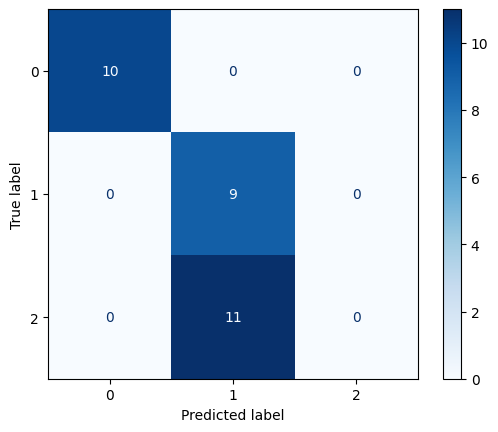

In [13]:
# Cria um Perceptron e o treina ( com o fit())
p = Perceptron( random_state=42 )
p.fit(X_train, y_train)

# Salva as predições do TESTE na variável y_pred
y_pred = p.predict(X_test)

# Matriz de confusão do Perceptron
from sklearn.metrics import confusion_matrix

def matrix_confusao(teste_labels, teste_preds, labels):
  cm = confusion_matrix(teste_labels, teste_preds, labels=labels)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues")

matrix_confusao(y_test, y_pred,p.classes_)


### Uma análise do resultado do Perceptron

- Resultado não foi muito bom ne? Mas faz sentido porque esse tipo de rede resolve bem problemas LINEARMENTE SEPARÁVEIS. Será que é o caso desde Dataset?

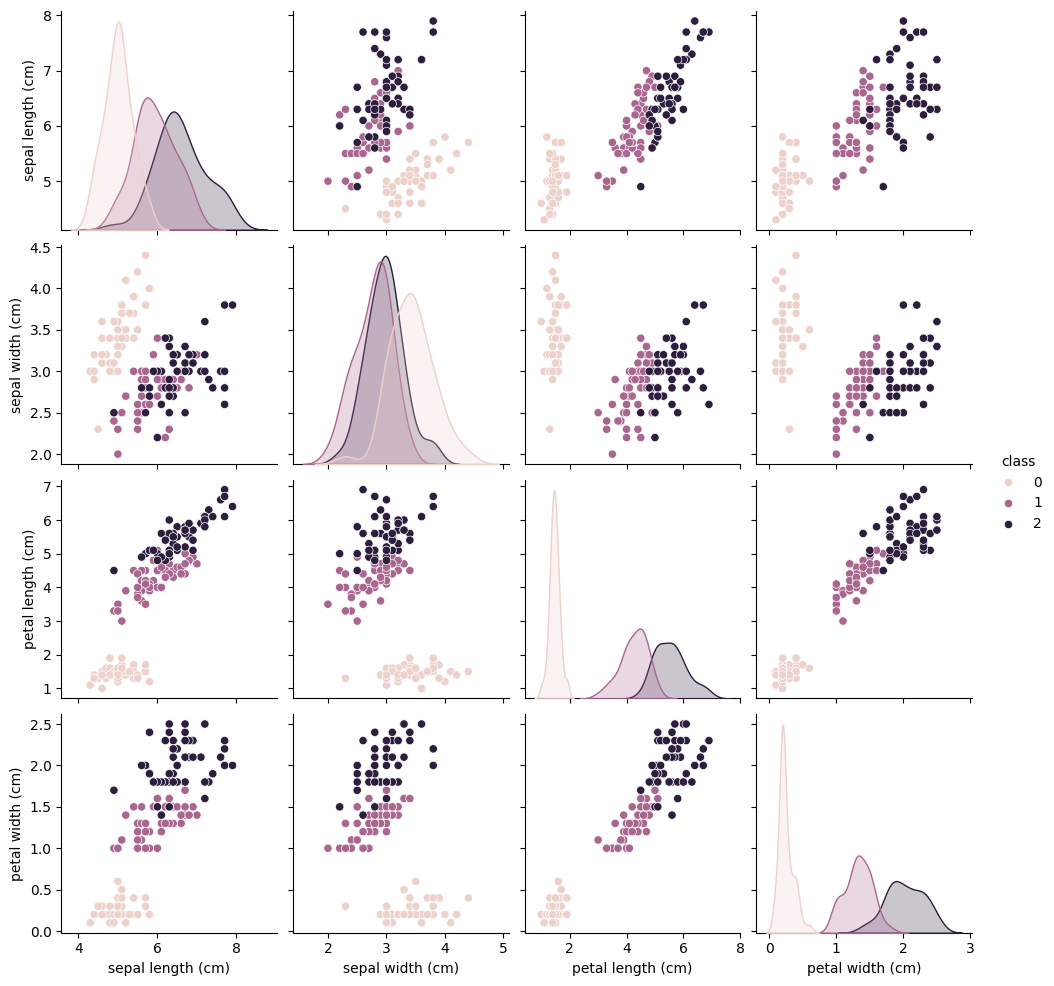

In [11]:
sns.pairplot( data=data, vars=('sepal length (cm)', \
                               'sepal width (cm)', \
                              'petal length (cm)', \
                               'petal width (cm)'), \
                               hue='class');

Iteration 1, loss = 2.08037493
Iteration 2, loss = 2.06532354
Iteration 3, loss = 2.05033268
Iteration 4, loss = 2.03525767
Iteration 5, loss = 2.02015639
Iteration 6, loss = 2.00505941
Iteration 7, loss = 1.99005943
Iteration 8, loss = 1.97508232
Iteration 9, loss = 1.96009013
Iteration 10, loss = 1.94520369
Iteration 11, loss = 1.93042694
Iteration 12, loss = 1.91568140
Iteration 13, loss = 1.90103579
Iteration 14, loss = 1.88631849
Iteration 15, loss = 1.87144170
Iteration 16, loss = 1.85650081
Iteration 17, loss = 1.84135841
Iteration 18, loss = 1.82623030
Iteration 19, loss = 1.81102525
Iteration 20, loss = 1.79576661
Iteration 21, loss = 1.78057518
Iteration 22, loss = 1.76543617
Iteration 23, loss = 1.75043564
Iteration 24, loss = 1.73557174
Iteration 25, loss = 1.72086287
Iteration 26, loss = 1.70630537
Iteration 27, loss = 1.69190475
Iteration 28, loss = 1.67767132
Iteration 29, loss = 1.66362040
Iteration 30, loss = 1.64973531
Iteration 31, loss = 1.63601784
Iteration 32, los

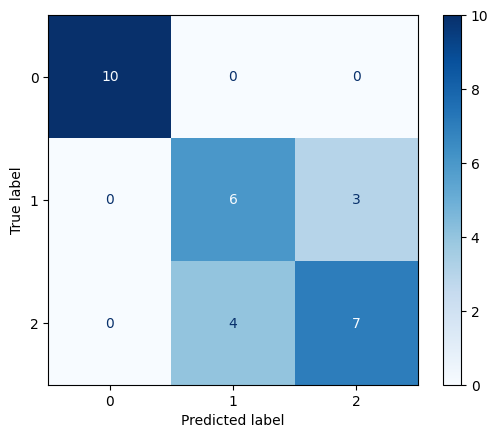

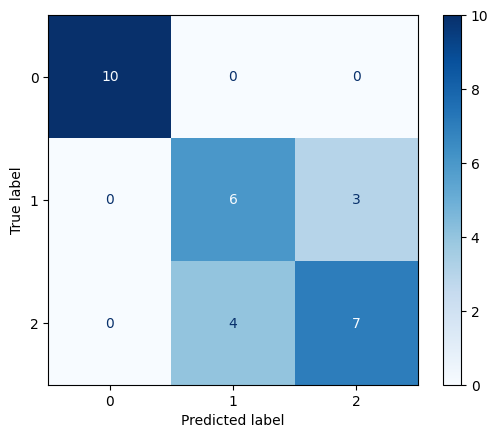

In [14]:
# Arquitetura
mlp = MLPClassifier(
    hidden_layer_sizes=(5,),
    verbose=True,
    max_iter=200,
    random_state=1
)

# Treinamento
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

# Matriz de confusão
matrix_confusao(y_test, y_pred,mlp.classes_)


# Avaliação
matrix_confusao(y_test, y_pred, mlp.classes_)

### Ajustando Parâmetros...

- Comparando os diferentes resultados alcançados com a alteração de parâmetros, fica clara (mais uma vez) a importância de ajustar esses parâmetros.

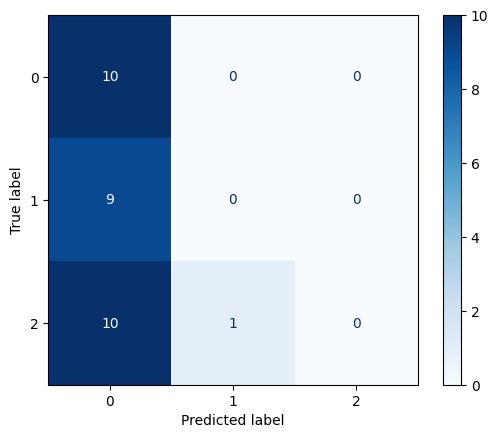

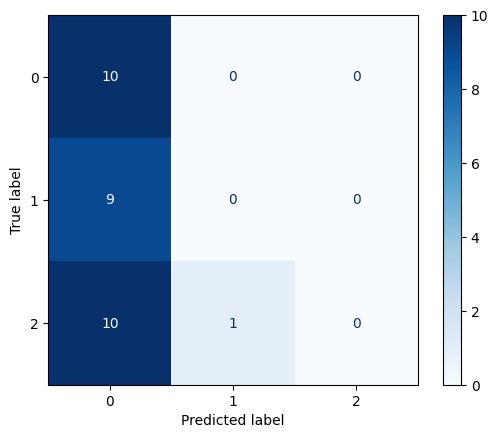

In [15]:
# Alterando a função de ativação...
mlp = MLPClassifier(
    hidden_layer_sizes=(5,),
    verbose=False,
    max_iter=50,
    random_state=1,
    activation='logistic'
)

# Treinamento
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

# Matriz de confusão
matrix_confusao(y_test, y_pred,mlp.classes_)


# Avaliação
matrix_confusao(y_test, y_pred, mlp.classes_)

ACC Teste:  1.0


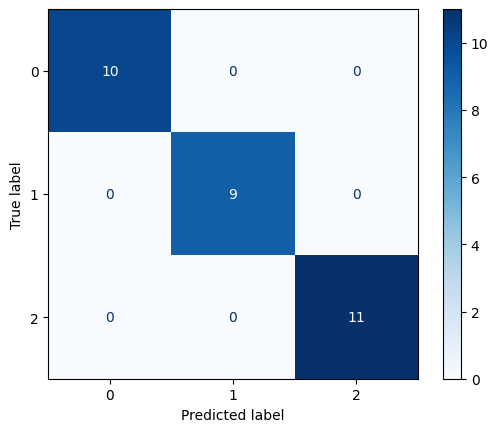

In [16]:
# Alterando o solver para o que a própria documentação aconselha pata Datasets menores
mlp = MLPClassifier(
    hidden_layer_sizes=(5,),
    verbose=False,
    max_iter=50,
    random_state=1,
    activation='logistic',
    solver='lbfgs'
)

# Treinamento
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("ACC Teste: ", accuracy_score(y_test, y_pred))

# Matriz de confusão
matrix_confusao(y_test, y_pred,mlp.classes_)



Iteration 1, loss = 1.17696538
Iteration 2, loss = 1.17591871
Iteration 3, loss = 1.17487912
Iteration 4, loss = 1.17384675
Iteration 5, loss = 1.17282172
Iteration 6, loss = 1.17180414
Iteration 7, loss = 1.17079412
Iteration 8, loss = 1.16979176
Iteration 9, loss = 1.16879718
Iteration 10, loss = 1.16781045
Iteration 11, loss = 1.16683167
Iteration 12, loss = 1.16586092
Iteration 13, loss = 1.16489828
Iteration 14, loss = 1.16394380
Iteration 15, loss = 1.16299756
Iteration 16, loss = 1.16205961
Iteration 17, loss = 1.16113000
Iteration 18, loss = 1.16020876
Iteration 19, loss = 1.15929594
Iteration 20, loss = 1.15839157
Iteration 21, loss = 1.15749565
Iteration 22, loss = 1.15660822
Iteration 23, loss = 1.15572927
Iteration 24, loss = 1.15485881
Iteration 25, loss = 1.15399683
Iteration 26, loss = 1.15314333
Iteration 27, loss = 1.15229828
Iteration 28, loss = 1.15146166
Iteration 29, loss = 1.15063344
Iteration 30, loss = 1.14981360
Iteration 31, loss = 1.14900209
Iteration 32, los

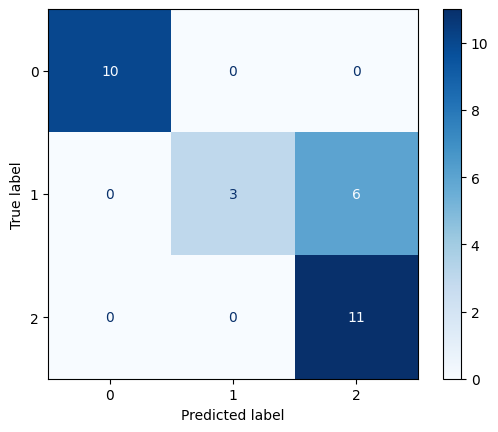

In [17]:
# Testando outra arquitetura...
mlp = MLPClassifier(
    hidden_layer_sizes=(5,3),
    verbose=True,
    max_iter=1000,
    random_state=1,
    activation='logistic',
    learning_rate="adaptive"
    solver='adam'
)

# Treinamento
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("ACC Teste: ", accuracy_score(y_test, y_pred))

# Matriz de confusão
matrix_confusao(y_test, y_pred,mlp.classes_)

ACC Teste:  1.0


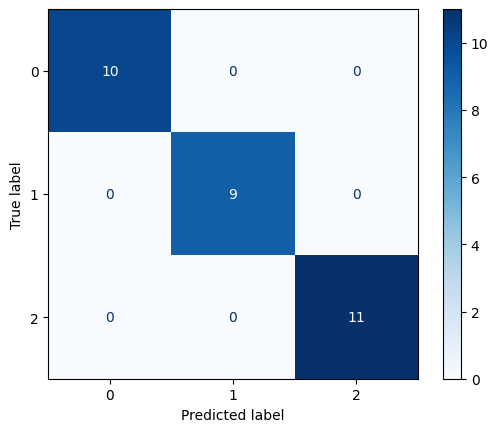

In [20]:
# Modelo com múltiplas camadas
mlp = MLPClassifier(
    hidden_layer_sizes=(5,3),
    solver="lbfgs"
)

# Treinamento
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("ACC Teste: ", accuracy_score(y_test, y_pred))

# Avaliação
matrix_confusao(y_test, y_pred, mlp.classes_)